In [47]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from numba import cuda

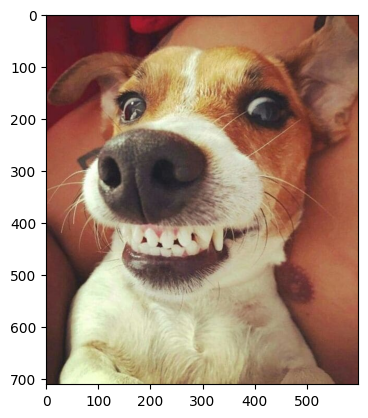

In [58]:
img = plt.imread("/content/dog.jpg")

plt.imshow(img)

In [59]:
height, width, channels = img.shape
print(f"{height} x {width}")

710 x 600


In [60]:
GAUSSIAN_FILTER = np.array([
    [0,  0,  1,   2,  1,  0,  0],
    [0,  3,  13, 22, 13,  3,  0],
    [1, 13,  59, 97, 59, 13,  1],
    [2, 22,  97, 159, 97, 22, 2],
    [1, 13,  59, 97, 59, 13,  1],
    [0,  3,  13, 22, 13,  3,  0],
    [0,  0,  1,   2,  1,  0,  0]
], dtype=np.float32)

GAUSSIAN_FILTER = GAUSSIAN_FILTER / 1003.0

CPU

In [61]:
def gaussian_blur_cpu(src, filter):
    height, width, channels = src.shape
    dst = np.zeros((height, width, channels), dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            for c in range(channels):
                result = 0.0
                for fy in range(-3, 4):
                    for fx in range(-3, 4):
                        ny = y + fy
                        nx = x + fx
                        # Border handling
                        if ny >= 0 and ny < height and nx >= 0 and nx < width:
                            result += (float(src[ny, nx, c]) * filter[fy + 3, fx + 3])
                dst[y, x, c] = np.uint8(result)

    return dst

In [24]:
start = time.time()

blur_cpu = gaussian_blur_cpu(img, GAUSSIAN_FILTER)

end = time.time()
cpu_time = end - start
print(f"CPU time: {cpu_time:.6f} seconds")

CPU time: 44.456276 seconds


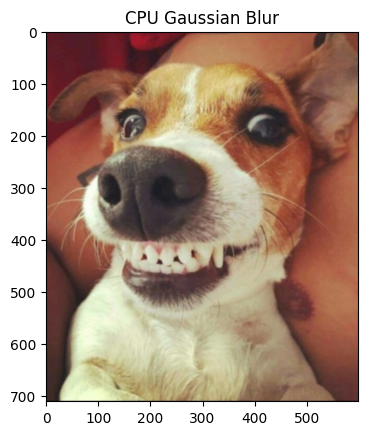

In [25]:
plt.imshow(blur_cpu)
plt.title("CPU Gaussian Blur")
plt.show()

plt.imsave("/content/gaus_cpu.png", blur_cpu)

GPU

In [62]:
height, width, channels = img.shape

In [63]:
devSrc = cuda.to_device(img)
devFilter = cuda.to_device(GAUSSIAN_FILTER)
devDst = cuda.device_array(img.shape, dtype=np.uint8)

In [64]:
blockSize = (32, 32)
gridSize = (math.ceil(width / blockSize[0]), math.ceil(height / blockSize[1]))

without shared memory

In [65]:
@cuda.jit
def gaussian_blur(src, dst, filter):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    height = src.shape[0]
    width = src.shape[1]
    channels = src.shape[2]

    if tidx < width and tidy < height:
        for c in range(channels):
            result = 0.0
            for fy in range(-3, 4):
                for fx in range(-3, 4):
                    nx = tidx + fx
                    ny = tidy + fy
                    if nx >= 0 and nx < width and ny >= 0 and ny < height:
                        result += (float(src[ny, nx, c]) * filter[fy + 3, fx + 3])
            dst[tidy, tidx, c] = np.uint8(result)

In [68]:
start = time.time()

gaussian_blur[gridSize, blockSize](devSrc, devDst, devFilter)

cuda.synchronize()
end = time.time()
gpu_time = end - start
print(f"Time without shared memory: {gpu_time:.6f} seconds")

Time without shared memory: 0.005323 seconds


In [69]:
speedup = cpu_time / gpu_time

print(f"CPU time: {cpu_time:.6f} seconds")
print(f"GPU time: {gpu_time:.6f} seconds")
print(f"Speedup: {speedup:.2f}x")

CPU time: 44.456276 seconds
GPU time: 0.005323 seconds
Speedup: 8352.21x


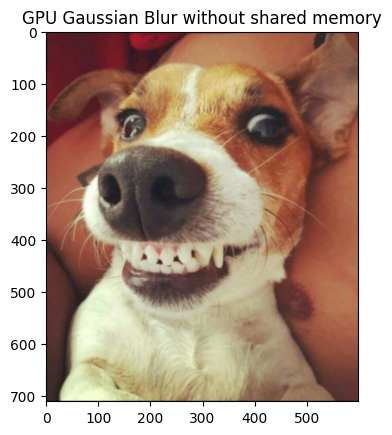

In [70]:
blur_gpu = devDst.copy_to_host()

plt.imshow(blur_gpu)
plt.title("GPU Gaussian Blur without shared memory")

plt.imsave("/content/gau_gpu.png", blur_gpu)

with shared memory

In [71]:
devDstShared = cuda.device_array(img.shape, dtype=np.uint8)

In [72]:
@cuda.jit
def gaussian_blur_shared(src, dst, filter):
    tile = cuda.shared.array((7, 7), dtype=np.float32)

    tidx = cuda.threadIdx.x
    tidy = cuda.threadIdx.y
    if tidx < 7 and tidy < 7:
        tile[tidy, tidx] = filter[tidy, tidx]

    cuda.syncthreads()

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    height = src.shape[0]
    width = src.shape[1]
    channels = src.shape[2]

    if tidx < width and tidy < height:
        for c in range(channels):
            result = 0.0
            for fy in range(-3, 4):
                for fx in range(-3, 4):
                    nx = tidx + fx
                    ny = tidy + fy
                    if nx >= 0 and nx < width and ny >= 0 and ny < height:
                        result += (float(src[ny, nx, c])* tile[fy + 3, fx + 3])
            dst[tidy, tidx, c] = np.uint8(result)

In [73]:
start = time.time()

gaussian_blur_shared[gridSize, blockSize](devSrc, devDstShared, devFilter)

cuda.synchronize()
end = time.time()
gpu_time_shared = end - start
print(f"Time with shared memory: {gpu_time_shared:.6f} seconds")

Time with shared memory: 0.376884 seconds


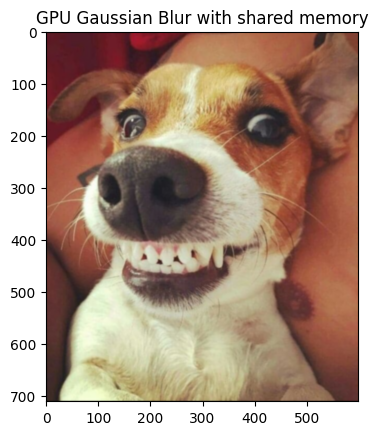

In [74]:
blur_gpu_shared = devDstShared.copy_to_host()

plt.imshow(blur_gpu_shared)
plt.title("GPU Gaussian Blur with shared memory")

plt.imsave("/content/gaus_gpu_shared.png", blur_gpu_shared)

In [45]:
speedup_shared = cpu_time / gpu_time_shared

print(f"CPU time: {cpu_time:.6f} seconds")
print(f"GPU time with shared memory: {gpu_time_shared:.6f} seconds")
print(f"Speedup: {speedup_shared:.2f}x")

CPU time: 44.456276 seconds
GPU time with shared memory: 0.264210 seconds
Speedup: 168.26x


In [76]:
block_2d = [(8, 4), (16, 4), (8, 16), (16, 16), (32, 16), (32, 32)]
gpu_times = []
speedups = []

for block in block_2d:
    block_x = block[0]
    block_y = block[1]
    blockSize_2D = (block_x, block_y)
    gridSize_2D = (math.ceil(width / block_x), math.ceil(height / block_y))

    start = time.time()

    gaussian_blur[gridSize_2D, blockSize_2D](devSrc, devDst, devFilter)

    cuda.synchronize()
    end = time.time()
    gpu_time = end - start
    speedup = cpu_time / gpu_time

    gpu_times.append(gpu_time)
    speedups.append(speedup)

    print(f"Block size: {block_x} x {block_y}")
    print(f"Grid size: {gridSize_2D}")
    print(f"Threads per block: {block_x * block_y}")
    print(f"GPU time: {gpu_time:.6f} seconds")
    print(f"Speedup: {speedup:.2f}x")
    print()

Block size: 8 x 4
Grid size: (75, 178)
Threads per block: 32
GPU time: 0.005332 seconds
Speedup: 8337.65x

Block size: 16 x 4
Grid size: (38, 178)
Threads per block: 64
GPU time: 0.004787 seconds
Speedup: 9286.94x

Block size: 8 x 16
Grid size: (75, 45)
Threads per block: 128
GPU time: 0.004719 seconds
Speedup: 9420.18x

Block size: 16 x 16
Grid size: (38, 45)
Threads per block: 256
GPU time: 0.004744 seconds
Speedup: 9370.48x

Block size: 32 x 16
Grid size: (19, 45)
Threads per block: 512
GPU time: 0.004807 seconds
Speedup: 9248.25x

Block size: 32 x 32
Grid size: (19, 23)
Threads per block: 1024
GPU time: 0.004942 seconds
Speedup: 8995.28x



In [78]:
gpu_times_shared = []
speedups_shared = []

for block in block_2d:
    block_x = block[0]
    block_y = block[1]
    blockSize_2D = (block_x, block_y)

    gridSize_2D = (math.ceil(width / block_x), math.ceil(height / block_y))

    start = time.time()
    gaussian_blur_shared[gridSize_2D, blockSize_2D](devSrc, devDst, devFilter)

    cuda.synchronize()
    end = time.time()
    gpu_time = end - start
    speedup = cpu_time / gpu_time

    gpu_times_shared.append(gpu_time)
    speedups_shared.append(speedup)

    print(f"Block size: {block_x} x {block_y}")
    print(f"Grid size: {gridSize_2D}")
    print(f"Threads per block: {block_x * block_y}")
    print(f"GPU time: {gpu_time:.6f} seconds")
    print(f"Speedup: {speedup:.2f}x")
    print()

Block size: 8 x 4
Grid size: (75, 178)
Threads per block: 32
GPU time: 0.004929 seconds
Speedup: 9019.65x

Block size: 16 x 4
Grid size: (38, 178)
Threads per block: 64
GPU time: 0.004824 seconds
Speedup: 9215.79x

Block size: 8 x 16
Grid size: (75, 45)
Threads per block: 128
GPU time: 0.004665 seconds
Speedup: 9529.96x

Block size: 16 x 16
Grid size: (38, 45)
Threads per block: 256
GPU time: 0.004676 seconds
Speedup: 9507.12x

Block size: 32 x 16
Grid size: (19, 45)
Threads per block: 512
GPU time: 0.004703 seconds
Speedup: 9452.18x

Block size: 32 x 32
Grid size: (19, 23)
Threads per block: 1024
GPU time: 0.004872 seconds
Speedup: 9124.69x



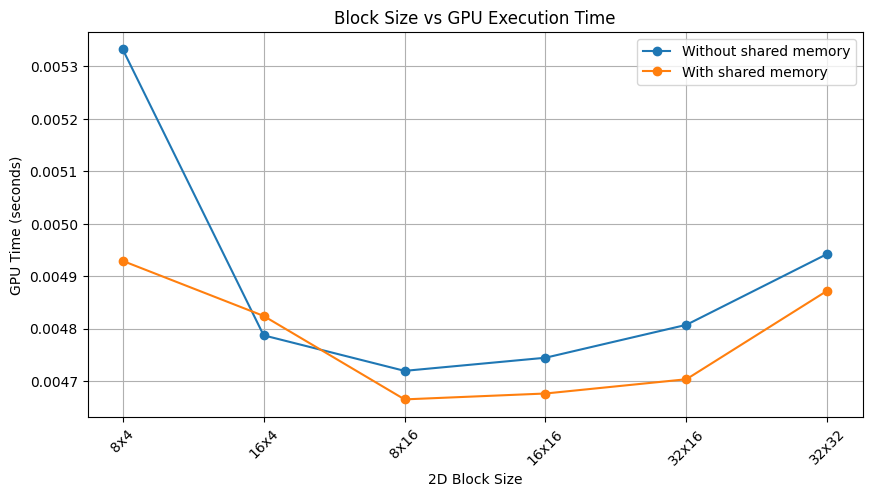

In [79]:
block_labels = [f"{x}x{y}" for x, y in block_2d]

plt.figure(figsize=(10, 5))
plt.plot(block_labels, gpu_times, marker="o", label="Without shared memory")
plt.plot(block_labels, gpu_times_shared, marker="o", label="With shared memory")
plt.xlabel("2D Block Size")
plt.ylabel("GPU Time (seconds)")
plt.title("Block Size vs GPU Execution Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

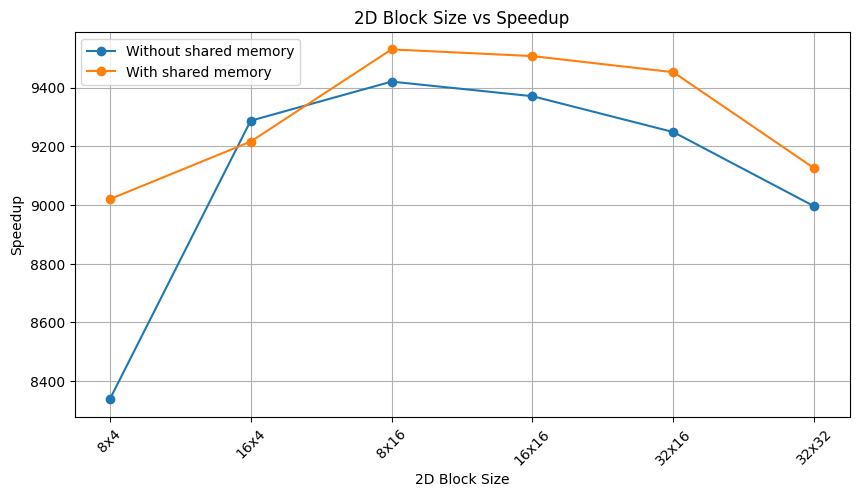

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(block_labels, speedups, marker="o", label="Without shared memory")
plt.plot(block_labels, speedups_shared, marker="o", label="With shared memory")
plt.xlabel("2D Block Size")
plt.ylabel("Speedup")
plt.title("2D Block Size vs Speedup")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)